# Selective synchrosqueezing

Ahrabian & Mandic, IEEE *Signal Processing Letters* 22(11), 2015.
Standard SST squeezes **signal and noise**. Selective SST first
windows the CWT, counts oscillatory modes à la RCM, hard-thresholds
coefficients below $\gamma$, and *then* reassigns. The TFR is easier
to read at low SNR and cheaper, because noise bins are never squeezed.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SST, EMD
from pysdkit.data import load_sst_float, load_sst_doppler

plt.rcParams["figure.dpi"] = 120
print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SST())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchrosqueezing Transform (SST)


## 2. FM pair in noise (SPL synthetic)


nonzero bins  full / selective: 58618 1238


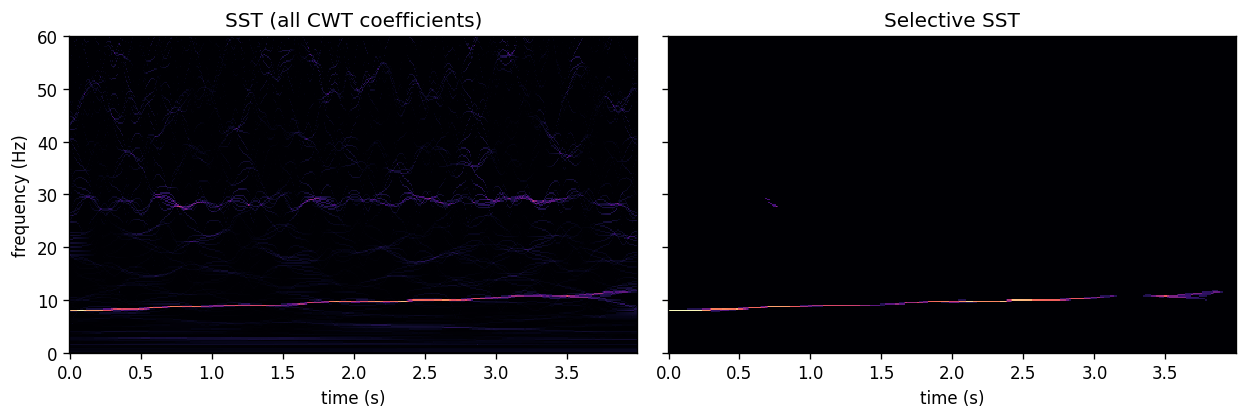

In [2]:
rng = np.random.default_rng(3)
fs = 200.0
t = np.arange(0.0, 4.0, 1.0 / fs)
fm = np.cos(2.0 * np.pi * (8.0 * t + 0.4 * t**2)) + 0.7 * np.cos(
    2.0 * np.pi * (28.0 * t + 0.15 * t**2)
)
x = fm + 0.9 * rng.standard_normal(t.size)

full = SST(n_voices=16, n_levels=4, wavelet="bump")
tfr_full, freq = full.transform(x)
sel = SST(n_voices=16, n_levels=4, wavelet="bump", n_window=32)
tfr_sel, _ = sel.selective_transform(x)
hz = freq * fs
print(
    "nonzero bins  full / selective:",
    np.count_nonzero(tfr_full),
    np.count_nonzero(tfr_sel),
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
axes[0].pcolormesh(t, hz, np.abs(tfr_full), shading="auto", cmap="magma")
axes[0].set_title("SST (all CWT coefficients)")
axes[0].set_ylabel("frequency (Hz)")
axes[0].set_xlabel("time (s)")
axes[0].set_ylim(0, 60)
axes[1].pcolormesh(t, hz, np.abs(tfr_sel), shading="auto", cmap="magma")
axes[1].set_title("Selective SST")
axes[1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

The left panel localises the background as well as the chirps. The
right panel keeps energy near the two FM ridges. Invert the masked
CWT (or the selective TFR) the same way as ordinary SST if a
time-domain reconstruction is required; the SPL paper notes that
hard thresholding makes that reconstruction *approximate*.
